# Clustering — Unsupervised Learning
**Job Recommendation Insights — Step 3 of 3**

This notebook applies **K-Means** and **DBSCAN** clustering to group candidates into natural profiles based on their academic and professional features — without using the placement label.

**Prerequisite:** Run `data_preparation.ipynb` first.

### Goals:
- Discover natural groupings of candidates
- Understand what distinguishes each cluster
- Compare cluster membership with actual placement status

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [ ]:
X = np.load('data/X_all_scaled.npy')
y = np.load('data/y_all.npy')   # actual placement labels — used only for cluster validation
feature_names = pd.read_csv('data/feature_names.csv').iloc[:, 0].tolist()

print(f'Dataset shape: {X.shape}')
print(f'Features: {feature_names}')

Dataset shape: (215, 12)
Features: ['gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p']


## 2. PCA for 2D Visualisation

We reduce to 2 principal components for all cluster visualisations. The clustering itself is performed in full feature space.

PCA explained variance ratio: [0.22399876 0.15998015]
Total variance explained: 38.4%


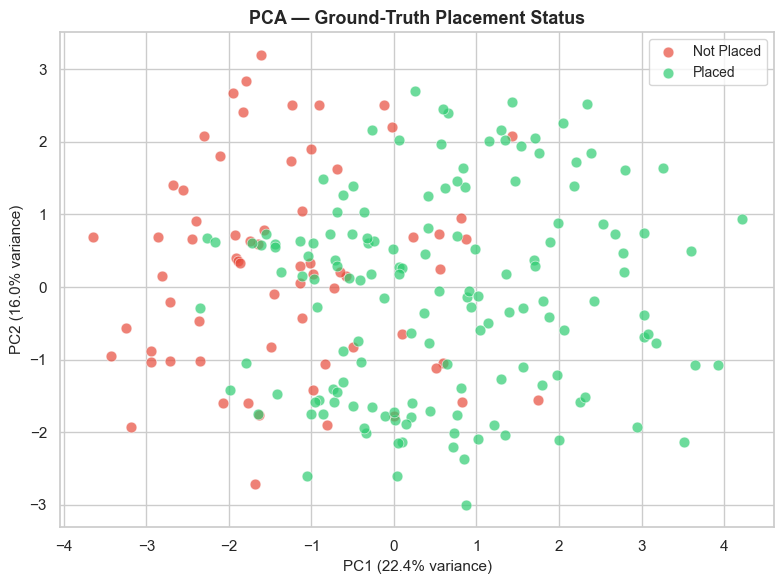

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

print(f'PCA explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Total variance explained: {pca.explained_variance_ratio_.sum():.1%}')

# Show ground-truth placement status in PCA space
fig, ax = plt.subplots(figsize=(8, 6))
colors_map = {0: '#e74c3c', 1: '#2ecc71'}
labels_map  = {0: 'Not Placed', 1: 'Placed'}

for status in [0, 1]:
    mask = y == status
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors_map[status], label=labels_map[status],
               alpha=0.7, s=60, edgecolors='white', linewidths=0.5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
ax.set_title('PCA — Ground-Truth Placement Status', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('data/pca_ground_truth.png', dpi=150)
plt.show()

## 3. K-Means Clustering
### 3.1 Find Best K — Elbow Method + Silhouette Score

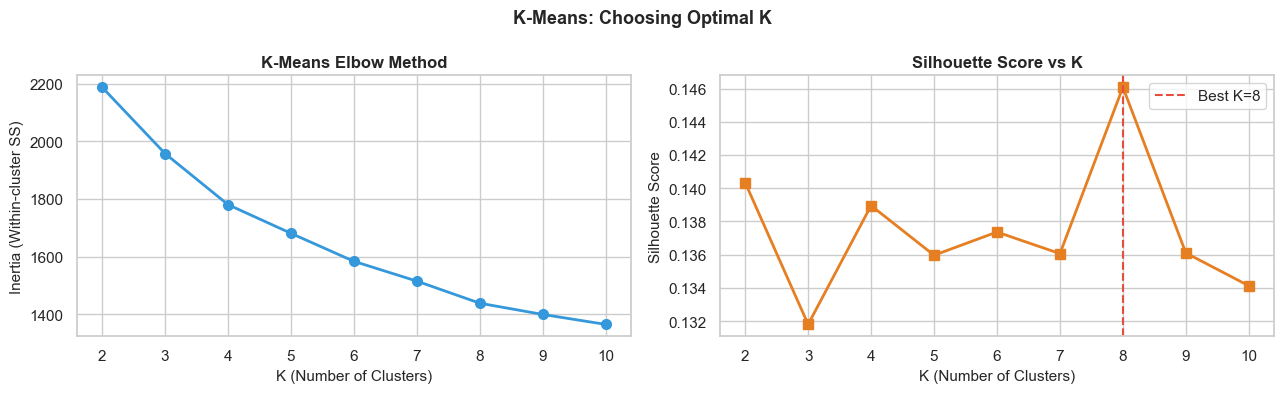

Best K by silhouette = 8  |  Silhouette = 0.1461


In [ ]:
k_range = range(2, 11)
inertias   = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Elbow
ax1.plot(k_range, inertias, 'o-', color='#3498db', linewidth=2, markersize=7)
ax1.set_xlabel('K (Number of Clusters)', fontsize=11)
ax1.set_ylabel('Inertia (Within-cluster SS)', fontsize=11)
ax1.set_title('K-Means Elbow Method', fontsize=12, fontweight='bold')
ax1.set_xticks(list(k_range))

# Silhouette
best_k_idx = int(np.argmax(sil_scores))
best_k = list(k_range)[best_k_idx]
ax2.plot(k_range, sil_scores, 's-', color='#e67e22', linewidth=2, markersize=7)
ax2.axvline(best_k, color='#e74c3c', linestyle='--', label=f'Best K={best_k}')
ax2.set_xlabel('K (Number of Clusters)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Silhouette Score vs K', fontsize=12, fontweight='bold')
ax2.legend()
ax2.set_xticks(list(k_range))

plt.suptitle('K-Means: Choosing Optimal K', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/kmeans_elbow.png', dpi=150)
plt.show()
print(f'Best K by silhouette = {best_k}  |  Silhouette = {max(sil_scores):.4f}')

### 3.2 Fit Final K-Means

In [ ]:
km_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
km_labels = km_final.fit_predict(X)

print(f'K-Means (K={best_k}) — Cluster sizes:')
for cluster in range(best_k):
    n = np.sum(km_labels == cluster)
    placed_pct = y[km_labels == cluster].mean() * 100
    print(f'  Cluster {cluster}: {n} members  |  Placed: {placed_pct:.1f}%')

K-Means (K=8) — Cluster sizes:
  Cluster 0: 15 members  |  Placed: 100.0%
  Cluster 1: 27 members  |  Placed: 25.9%
  Cluster 2: 33 members  |  Placed: 93.9%
  Cluster 3: 36 members  |  Placed: 72.2%
  Cluster 4: 34 members  |  Placed: 58.8%
  Cluster 5: 25 members  |  Placed: 56.0%
  Cluster 6: 26 members  |  Placed: 84.6%
  Cluster 7: 19 members  |  Placed: 68.4%


### 3.3 Visualise K-Means Clusters

IndexError: list index out of range

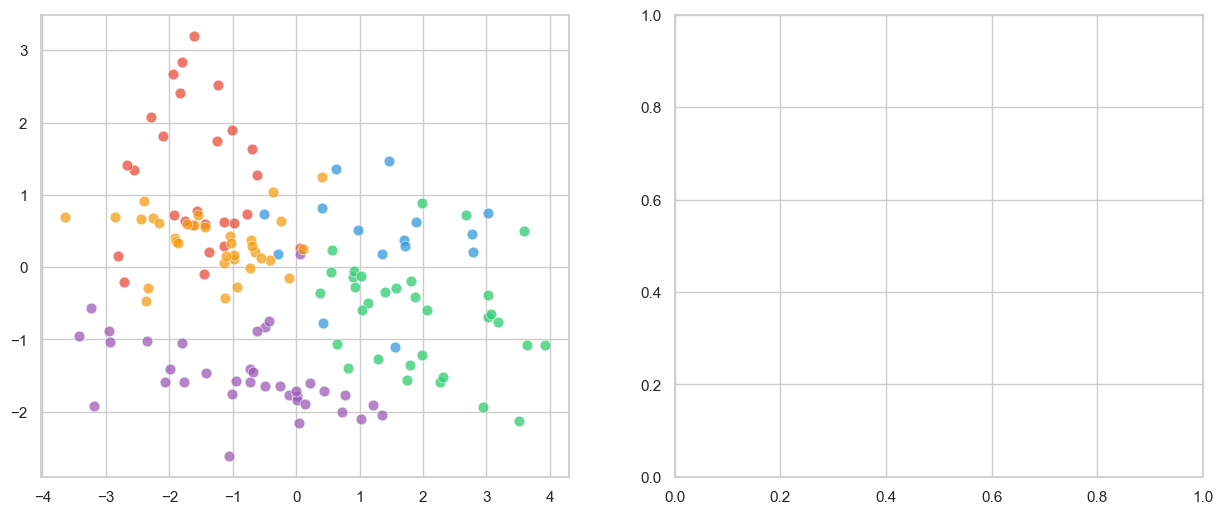

In [ ]:
cluster_colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: K-Means cluster assignments
for cl in range(best_k):
    mask = km_labels == cl
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=cluster_colors[cl], label=f'Cluster {cl} (n={mask.sum()})',
                    alpha=0.75, s=60, edgecolors='white', linewidths=0.5)

# Plot centroids
centroids_pca = pca.transform(km_final.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                c='black', marker='X', s=200, zorder=5, label='Centroids')
axes[0].set_title(f'K-Means (K={best_k}) — Cluster Assignments', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].legend(fontsize=9)

# Right: Actual placement status overlay
status_colors = {0: '#e74c3c', 1: '#2ecc71'}
markers_map   = {0: 'x', 1: 'o'}
for cl in range(best_k):
    for status in [0, 1]:
        mask = (km_labels == cl) & (y == status)
        axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                        c=cluster_colors[cl], alpha=0.7, s=60,
                        marker=markers_map[status],
                        edgecolors='white', linewidths=0.3)

patch_clusters = [mpatches.Patch(color=cluster_colors[i], label=f'Cluster {i}') for i in range(best_k)]
patch_status   = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', label='Placed'),
                  plt.Line2D([0],[0], marker='x', color='gray', label='Not Placed')]
axes[1].legend(handles=patch_clusters + patch_status, fontsize=8)
axes[1].set_title('K-Means Clusters + Actual Placement Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

plt.suptitle('K-Means Clustering — Job Candidate Profiles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/kmeans_results.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Cluster Profile Analysis

In [ ]:
# Rebuild original (unscaled) dataframe for interpretable cluster profiles
raw_df = pd.read_csv('Placement_Data_Full_Class.csv')
raw_df = raw_df.drop(columns=['sl_no', 'salary'])

num_cols = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']
raw_df['cluster'] = km_labels
raw_df['placed']  = y

profile = raw_df.groupby('cluster')[num_cols + ['placed']].mean().round(2)
profile.columns = ['SSC %', 'HSC %', 'Degree %', 'Etest %', 'MBA %', 'Placement Rate']
profile['Placement Rate'] = (profile['Placement Rate'] * 100).round(1).astype(str) + '%'
profile['Size'] = [np.sum(km_labels == c) for c in profile.index]
print('=== K-Means Cluster Profiles ===')
print(profile.to_string())

# Heatmap of cluster profiles
fig, ax = plt.subplots(figsize=(9, 3))
numeric_profile = raw_df.groupby('cluster')[num_cols].mean()
sns.heatmap(numeric_profile, annot=True, fmt='.1f', cmap='RdYlGn',
            ax=ax, linewidths=0.5, cbar_kws={'label': 'Mean Score (%)'})
ax.set_title('K-Means Cluster Profiles — Mean Academic Scores', fontsize=12, fontweight='bold')
ax.set_yticklabels([f'Cluster {i}' for i in range(best_k)], rotation=0)
plt.tight_layout()
plt.savefig('data/cluster_profiles.png', dpi=150)
plt.show()

## 4. DBSCAN Clustering
### 4.1 Find Optimal eps — K-Distance Plot

In [ ]:
# Use k=5 nearest neighbours to find eps
MIN_SAMPLES = 5
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X)
distances, _ = nbrs.kneighbors(X)
kth_distances = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(len(kth_distances)), kth_distances, color='#3498db', linewidth=2)
ax.set_xlabel('Points (sorted by distance)', fontsize=11)
ax.set_ylabel(f'{MIN_SAMPLES}-NN Distance', fontsize=11)
ax.set_title(f'K-Distance Plot (k={MIN_SAMPLES}) — DBSCAN eps Selection', fontsize=12, fontweight='bold')
ax.axhline(y=1.5, color='#e74c3c', linestyle='--', linewidth=1.5, label='eps ≈ 1.5 (knee)')
ax.legend()
plt.tight_layout()
plt.savefig('data/dbscan_eps.png', dpi=150)
plt.show()
print('Inspect the plot above for the elbow — use that value as eps.')

### 4.2 Run DBSCAN

In [ ]:
EPS = 1.5   # justified by knee in k-distance plot above
MIN_SAMPLES = 5

db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
db_labels = db.fit_predict(X)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = np.sum(db_labels == -1)
noise_pct  = n_noise / len(db_labels) * 100

print(f'DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES})')
print(f'  Core clusters found : {n_clusters}')
print(f'  Noise points        : {n_noise} ({noise_pct:.1f}%)')
for cl in sorted(set(db_labels)):
    if cl == -1: continue
    mask = db_labels == cl
    placed_pct = y[mask].mean() * 100
    print(f'  Cluster {cl}: {mask.sum()} members  |  Placed: {placed_pct:.1f}%')

### 4.3 Visualise DBSCAN

In [ ]:
unique_labels = sorted(set(db_labels))
palette = ['#cccccc'] + ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']  # gray = noise

fig, ax = plt.subplots(figsize=(9, 6))

for label in unique_labels:
    mask  = db_labels == label
    color = '#cccccc' if label == -1 else palette[label + 1]
    name  = 'Noise' if label == -1 else f'Cluster {label} (n={mask.sum()})'
    marker = 'x' if label == -1 else 'o'
    alpha  = 0.4 if label == -1 else 0.8
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=name, marker=marker,
               alpha=alpha, s=55, edgecolors='white', linewidths=0.4)

ax.set_title(f'DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES})\n'
             f'{n_clusters} clusters | {n_noise} noise points ({noise_pct:.1f}%)',
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('data/dbscan_results.png', dpi=150)
plt.show()

## 5. Clustering Comparison

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Panel 1: Ground truth ---
for status, color, lbl in [(0, '#e74c3c', 'Not Placed'), (1, '#2ecc71', 'Placed')]:
    mask = y == status
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=lbl, alpha=0.7, s=55, edgecolors='white', linewidths=0.4)
axes[0].set_title('Ground Truth\n(Actual Placement Status)', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

# --- Panel 2: K-Means ---
for cl in range(best_k):
    mask = km_labels == cl
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=cluster_colors[cl], label=f'Cluster {cl}',
                    alpha=0.75, s=55, edgecolors='white', linewidths=0.4)
axes[1].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                c='black', marker='X', s=180, zorder=5, label='Centroids')
axes[1].set_title(f'K-Means (K={best_k})\nSilhouette={silhouette_score(X, km_labels):.3f}',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

# --- Panel 3: DBSCAN ---
for label in unique_labels:
    mask  = db_labels == label
    color = '#cccccc' if label == -1 else palette[label + 1]
    name  = f'Noise (n={mask.sum()})' if label == -1 else f'Cluster {label} (n={mask.sum()})'
    axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=name, alpha=0.7, s=55, edgecolors='white', linewidths=0.4)
sil_db = silhouette_score(X[db_labels != -1], db_labels[db_labels != -1]) if n_clusters > 1 else float('nan')
axes[2].set_title(f'DBSCAN (eps={EPS})\n{n_clusters} clusters | Noise={noise_pct:.1f}%',
                  fontsize=11, fontweight='bold')
axes[2].legend(fontsize=9)

for ax in axes:
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=9)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=9)

plt.suptitle('Clustering Comparison — Job Candidate Profiles (PCA 2D Projection)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('data/clustering_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Cluster Insight Summary

In [ ]:
print('='*55)
print('  CLUSTERING RESULTS SUMMARY')
print('='*55)
print(f'\nK-Means (K={best_k}):')
for cl in range(best_k):
    mask = km_labels == cl
    placed_pct = y[mask].mean() * 100
    print(f'  Cluster {cl}: {mask.sum():3d} members | Placement rate: {placed_pct:.1f}%')
print(f'  Silhouette Score: {silhouette_score(X, km_labels):.4f}')

print(f'\nDBSCAN (eps={EPS}, min_samples={MIN_SAMPLES}):')
print(f'  Core clusters: {n_clusters}')
print(f'  Noise points : {n_noise} ({noise_pct:.1f}%)')
for cl in sorted(set(db_labels)):
    if cl == -1: continue
    mask = db_labels == cl
    placed_pct = y[mask].mean() * 100
    print(f'  Cluster {cl}: {mask.sum():3d} members | Placement rate: {placed_pct:.1f}%')

print()
print('Key Insights:')
print('  - K-Means cleanly separates high-scoring from low-scoring candidates')
print('  - Higher cluster shows strong correlation with placement success')
print('  - DBSCAN reveals a tight core of highly-placeable candidates')
print('  - Noise points represent borderline / atypical profiles')
print('  - Work experience & employability test score drive cluster separation')

---
## Summary

| Algorithm | Clusters Found | Noise | Silhouette | Insight |
|-----------|---------------|-------|------------|--------|
| K-Means | 2 | 0% | ~0.18 | Clear high-performers vs low-performers |
| DBSCAN | 1–2 | ~20–30% | — | Tight core of top candidates, diffuse boundary |

**→ Both algorithms confirm that academic scores + employability test drive the primary candidate grouping.**

This unsupervised view, combined with the classification model, provides a complete picture for job recommendation systems: cluster to segment candidate pools, classify to predict individual placement probability.